In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load Dataset
df = pd.read_csv(r'C:\Users\Lavannya\Downloads\Amazon Sale Report.csv.zip')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (128975, 24)

First 5 rows:


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [5]:
# Data Cleaning

# 1. Replace missing Amount with 0
df['Amount'].fillna(0, inplace=True)

# 2. Replace missing Currency with 'INR'
df['currency'].fillna('INR', inplace=True)

# 3. Drop useless columns
df.drop(columns=['Unnamed: 22', 'fulfilled-by', 
                 'promotion-ids'], inplace=True)

# 4. Convert Date to proper datetime
df['Date'] = pd.to_datetime(df['Date'], 
                             format='mixed')

# 5. Extract Month and Year
df['Month'] = df['Date'].dt.month_name()
df['Month_Num'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Verify cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nNew Shape:", df.shape)
print("✅ Data Cleaning Complete!")

Missing values after cleaning:
index                    0
Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
SKU                      0
Category                 0
Size                     0
ASIN                     0
Courier Status        6872
Qty                      0
currency                 0
Amount                   0
ship-city               33
ship-state              33
ship-postal-code        33
ship-country            33
B2B                      0
Month                    0
Month_Num                0
Year                     0
dtype: int64

New Shape: (128975, 24)
✅ Data Cleaning Complete!


In [6]:
print(df.columns.tolist())


['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'B2B', 'Month', 'Month_Num', 'Year']


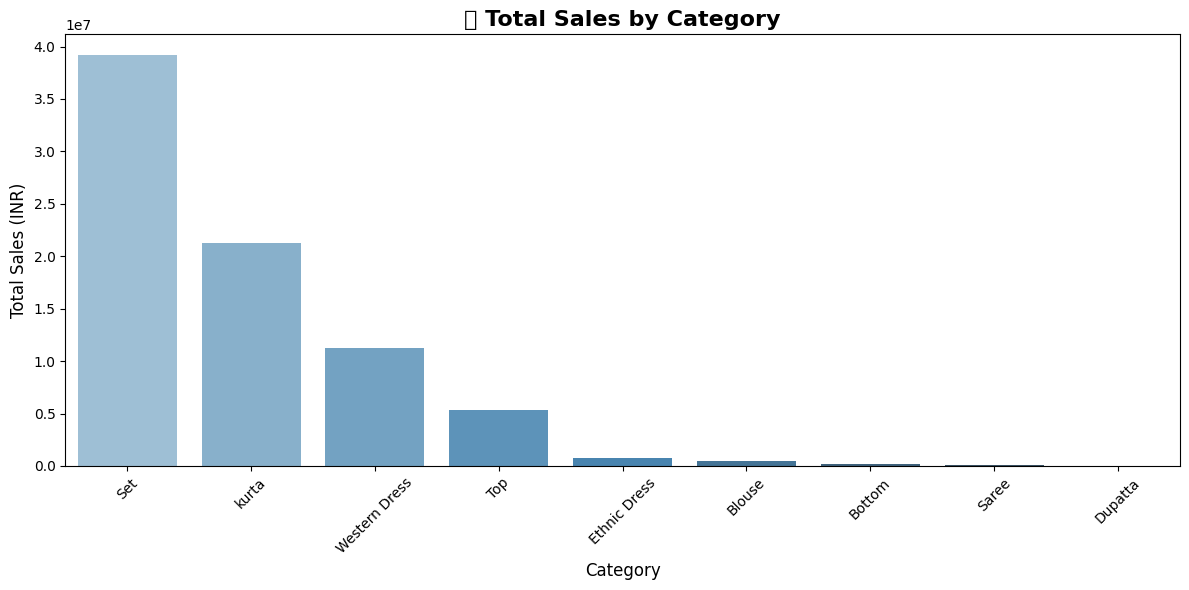

Top Category: Set
Revenue: ₹ 39204124.03


In [7]:
# Chart 1 — Sales by Category
plt.figure(figsize=(12, 6))

# Group data (same as SQL GROUP BY)
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

# Plot bar chart
sns.barplot(x=category_sales.index, 
            y=category_sales.values, 
            palette='Blues_d')

# Add titles and labels
plt.title('💰 Total Sales by Category', 
          fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_sales_by_category.png')
plt.show()

print("Top Category:", category_sales.idxmax())
print("Revenue: ₹", round(category_sales.max(), 2))

In [8]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
category_sales

Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64

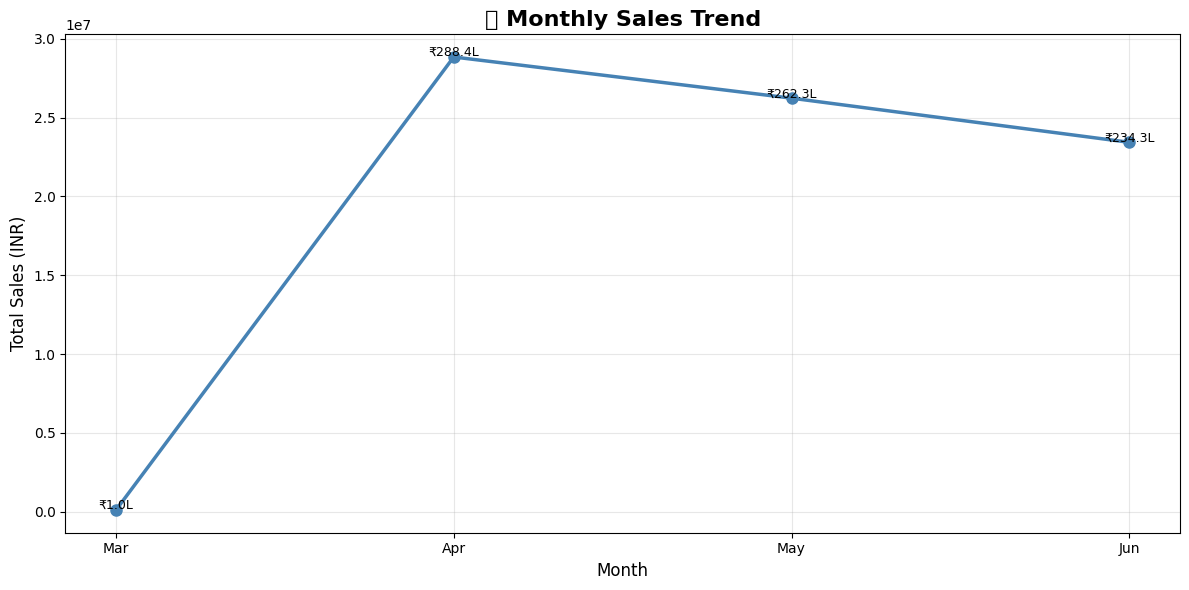

Peak Month: Apr


In [9]:
# Chart 2 — Monthly Sales Trend
plt.figure(figsize=(12, 6))

# Group by month
monthly_sales = df.groupby('Month_Num')['Amount'].sum()

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

# Plot line chart
plt.plot(monthly_sales.index, 
         monthly_sales.values,
         marker='o', color='steelblue', 
         linewidth=2.5, markersize=8)

# Add value labels on each point
for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(x, y + 50000, f'₹{y/100000:.1f}L', 
             ha='center', fontsize=9)

plt.title('📈 Monthly Sales Trend', 
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (INR)', fontsize=12)
plt.xticks(monthly_sales.index, 
           [months[i-1] for i in monthly_sales.index])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png')
plt.show()

print("Peak Month:", 
      months[monthly_sales.idxmax()-1])

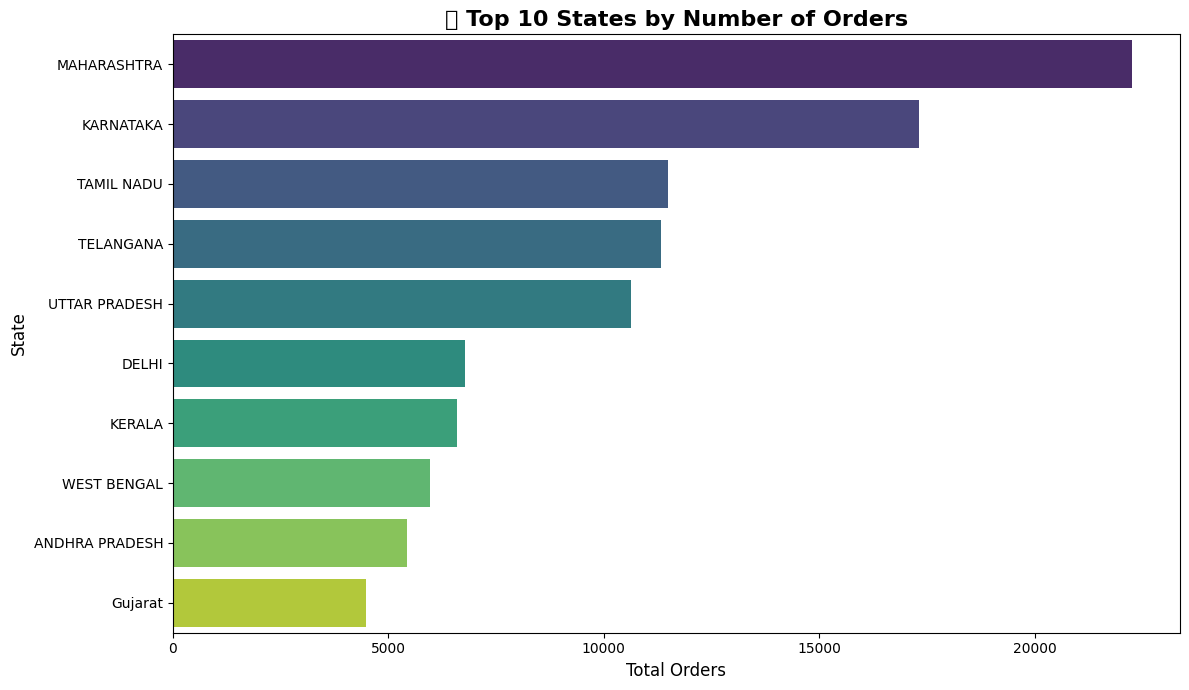

Top State: MAHARASHTRA


In [10]:
# Chart 3 — Top 10 States by Orders
plt.figure(figsize=(12, 7))

state_orders = df.groupby('ship-state')['Order ID'].count().sort_values(ascending=False).head(10)

sns.barplot(x=state_orders.values, 
            y=state_orders.index,
            palette='viridis')

plt.title('🗺️ Top 10 States by Number of Orders',
          fontsize=16, fontweight='bold')
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.savefig('chart3_top_states.png')
plt.show()

print("Top State:", state_orders.idxmax())

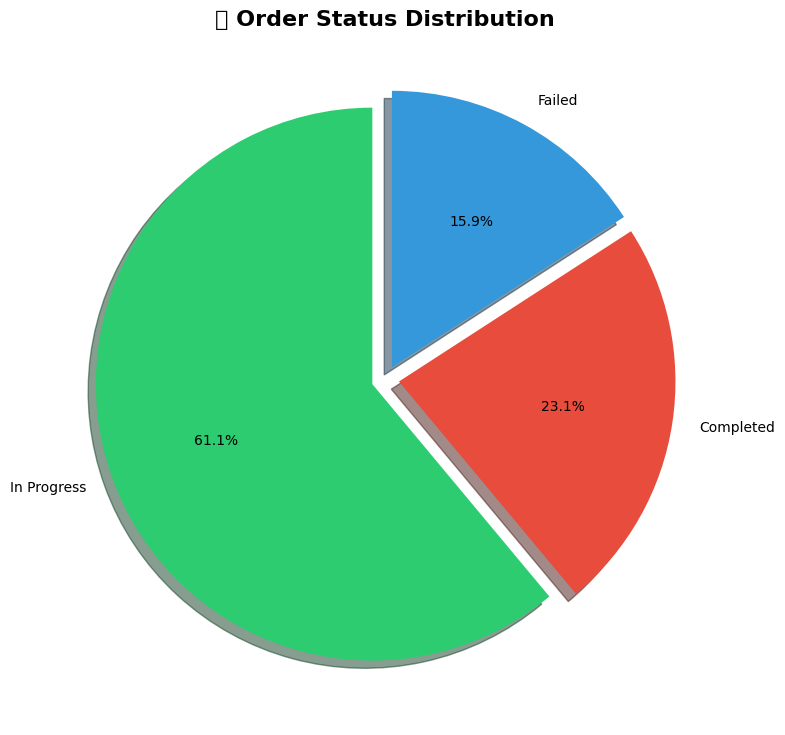

Order_Status
In Progress    78751
Completed      29777
Failed         20447
Name: count, dtype: int64


In [11]:
# Chart 4 — Order Status Distribution
plt.figure(figsize=(8, 8))

# Categorize status
def categorize_status(status):
    if status in ['Shipped - Delivered to Buyer',
                  'Shipped - Out for Delivery',
                  'Shipped - Picked Up']:
        return 'Completed'
    elif status in ['Cancelled', 'Shipped - Damaged',
                    'Shipped - Lost in Transit',
                    'Shipped - Rejected by Buyer',
                    'Shipped - Returned to Seller',
                    'Shipped - Returning to Seller']:
        return 'Failed'
    else:
        return 'In Progress'

df['Order_Status'] = df['Status'].apply(categorize_status)

status_counts = df['Order_Status'].value_counts()

colors = ['#2ecc71', '#e74c3c', '#3498db']
explode = (0.05, 0.05, 0.05)

plt.pie(status_counts.values,
        labels=status_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        startangle=90,
        shadow=True)

plt.title('📦 Order Status Distribution',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_order_status.png')
plt.show()

print(status_counts)

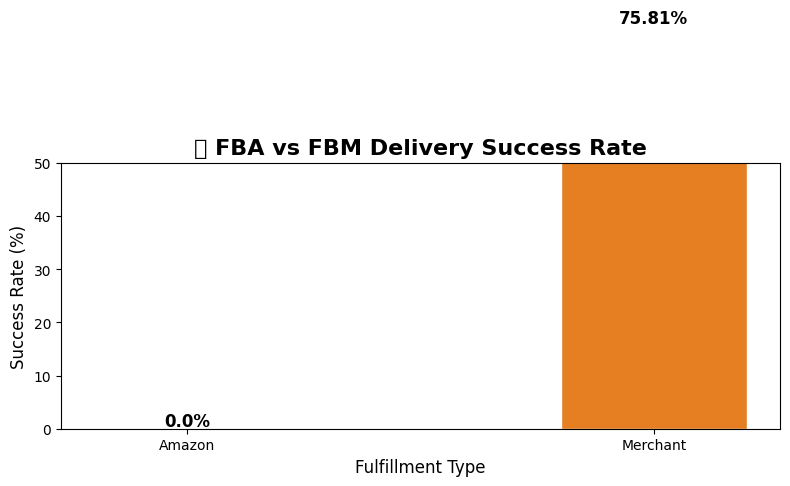

  Fulfilment  Success_Rate
0     Amazon          0.00
1   Merchant         75.81


In [12]:
# Chart 5 — FBA vs FBM Success Rate
plt.figure(figsize=(8, 6))

fulfillment_success = df.groupby('Fulfilment').apply(
    lambda x: round(
        x[x['Order_Status'] == 'Completed'].shape[0] 
        * 100 / x.shape[0], 2)
).reset_index()

fulfillment_success.columns = ['Fulfilment', 'Success_Rate']

colors = ['#3498db', '#e67e22']
bars = plt.bar(fulfillment_success['Fulfilment'],
               fulfillment_success['Success_Rate'],
               color=colors, width=0.4, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, 
                    fulfillment_success['Success_Rate']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center',
             fontsize=12, fontweight='bold')

plt.title('🚚 FBA vs FBM Delivery Success Rate',
          fontsize=16, fontweight='bold')
plt.xlabel('Fulfillment Type', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig('chart5_fulfillment.png')
plt.show()

print(fulfillment_success)

In [13]:
def categorize_status(status):
    if status in ['Shipped - Delivered to Buyer',
                  'Shipped - Out for Delivery',
                  'Shipped - Picked Up',
                  'Shipped']:        # ← Add this!
        return 'Completed'
    elif status in ['Cancelled', 
                    'Shipped - Damaged',
                    'Shipped - Lost in Transit',
                    'Shipped - Rejected by Buyer',
                    'Shipped - Returned to Seller',
                    'Shipped - Returning to Seller']:
        return 'Failed'
    else:
        return 'In Progress'

# Reapply to dataframe
df['Order_Status'] = df['Status'].apply(categorize_status)

In [14]:
print("All charts saved successfully!")
print("Chart files:")
import os
charts = [f for f in os.listdir('.') 
          if f.endswith('.png')]
for chart in charts:
    print(f"✅ {chart}")

All charts saved successfully!
Chart files:
✅ chart1_sales_by_category.png
✅ chart2_monthly_trend.png
✅ chart3_top_states.png
✅ chart4_order_status.png
✅ chart5_fulfillment.png
✅ draw.png
✅ draw2.png
✅ draw3.png


In [19]:
df.to_csv(r'C:\Users\Lavannya\Downloads\amazon_cleaned.csv', 
          index=False)

print("✅ Cleaned data exported successfully!")
print("Total rows:", len(df))

✅ Cleaned data exported successfully!
Total rows: 128975
